In [4]:
## 1. Import numpy and matplotlib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
# 2. Data Description
data = pd.read_csv("Data.csv")

print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (1308, 16)
   lp    lf   sw  l1  l2  l3  l4   s1   s2   s3   s4   l   w  \
0  30  34.0  1.6  22  16  10   6  1.8  1.8  1.8  1.8  65  56   
1  30  32.0  1.6  26  20  10   6  1.8  1.8  1.8  1.8  65  56   
2  30  36.0  1.6  22  16  10   6  2.2  2.2  2.2  1.8  65  56   
3  30  32.0  2.8  22  16  10   6  1.8  1.8  1.8  1.8  65  56   
4  30  36.0  2.8  22  16  10   6  1.8  1.8  1.8  2.2  65  56   

   resonant_freq_GHz  min_S11_dB  gain_db  
0              2.044  -21.427998    1.618  
1              2.040  -20.117951    1.421  
2              2.048  -24.235290    2.172  
3              1.976  -19.124457    1.248  
4              1.968  -15.725323    1.176  


In [7]:
## 3.Data Features
X = data[
    [
        "lp", "lf", "sw",
        "l1", "l2", "l3", "l4",
        "s1", "s2", "s3", "s4",
        "l", "w"
    ]
]

y_freq = data["resonant_freq_GHz"]
y_s11  = data["min_S11_dB"]
y_gain = data["gain_db"]   

In [9]:
## 4. Train-Test Split
X_train, X_test, y_freq_train, y_freq_test, y_s11_train, y_s11_test, y_gain_train, y_gain_test = train_test_split(
    X, y_freq, y_s11, y_gain,
    test_size=0.2,
    random_state=42
)

In [10]:
## 5. Random Forest Model – Frequency Prediction
rf_freq_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_freq_model.fit(X_train, y_freq_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
## 6. Model Evaluation – Frequency Prediction
y_freq_pred_rf = rf_freq_model.predict(X_test)

print("Random Forest – Frequency Prediction Performance")
print("MAE :", mean_absolute_error(y_freq_test, y_freq_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_freq_test, y_freq_pred_rf)))
print("R²  :", r2_score(y_freq_test, y_freq_pred_rf))

Random Forest – Frequency Prediction Performance
MAE : 0.00015358630638084337
RMSE: 0.0010941811762127177
R²  : 0.9985516217983966


In [12]:
## 7. Random Forest Model Training for S11 Prediction
rf_s11_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_s11_model.fit(X_train, y_s11_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
## 8. Model Evaluation – S11 Prediction
y_s11_pred_rf = rf_s11_model.predict(X_test)

print("\nRandom Forest – S11 Prediction Performance")
print("MAE :", mean_absolute_error(y_s11_test, y_s11_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_s11_test, y_s11_pred_rf)))
print("R²  :", r2_score(y_s11_test, y_s11_pred_rf))


Random Forest – S11 Prediction Performance
MAE : 0.1479523934980859
RMSE: 1.0165780422782624
R²  : 0.946434962041012


In [14]:
## 9. Random Forest Model Training for Gain Prediction
rf_gain_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_gain_model.fit(X_train, y_gain_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
## 10. Model Evaluation – Gain Prediction
y_gain_pred_rf = rf_gain_model.predict(X_test)

print("\nRandom Forest – Gain Prediction Performance")
print("MAE :", mean_absolute_error(y_gain_test, y_gain_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_gain_test, y_gain_pred_rf)))
print("R²  :", r2_score(y_gain_test, y_gain_pred_rf))


Random Forest – Gain Prediction Performance
MAE : 0.0033394809390432456
RMSE: 0.018142631521463788
R²  : -1.8117469413773275


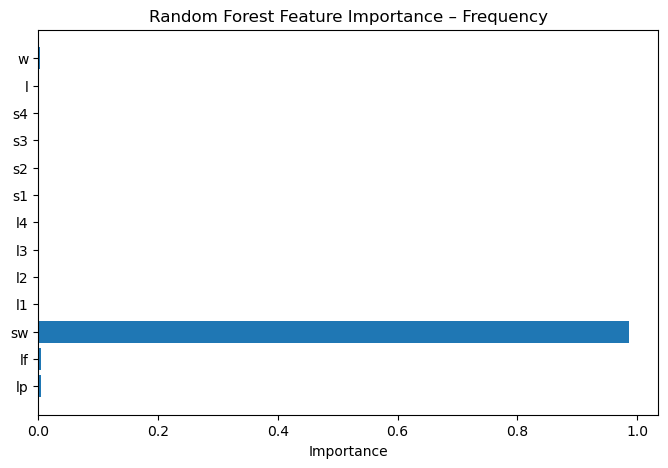

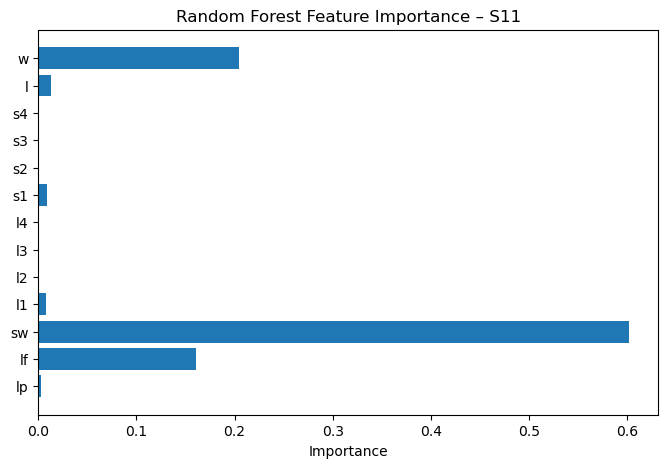

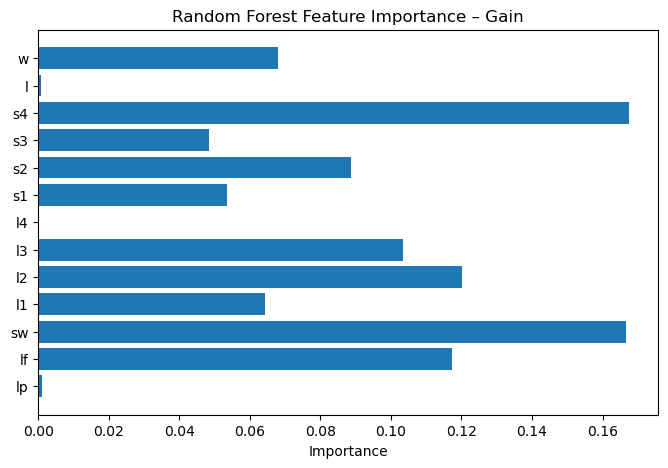

In [16]:
# Frequency
plt.figure(figsize=(8, 5))
plt.barh(X.columns, rf_freq_model.feature_importances_)
plt.title("Random Forest Feature Importance – Frequency")
plt.xlabel("Importance")
plt.show()

# S11
plt.figure(figsize=(8, 5))
plt.barh(X.columns, rf_s11_model.feature_importances_)
plt.title("Random Forest Feature Importance – S11")
plt.xlabel("Importance")
plt.show()

# Gain
plt.figure(figsize=(8, 5))
plt.barh(X.columns, rf_gain_model.feature_importances_)
plt.title("Random Forest Feature Importance – Gain")
plt.xlabel("Importance")
plt.show()

In [17]:
## 12. User Input and Model Prediction
print("\nEnter Antenna Parameters (Random Forest Prediction):")

Lp = float(input("Enter Patch Length Lp (mm): "))
Lf = float(input("Enter Feed Length Lf (mm): "))
Sw = float(input("Enter Stub Height Sw (mm): "))

L1 = float(input("Enter Director Length L1 (mm): "))
L2 = float(input("Enter Director Length L2 (mm): "))
L3 = float(input("Enter Director Length L3 (mm): "))
L4 = float(input("Enter Director Length L4 (mm): "))

s1 = float(input("Enter Director Spacing s1 (mm): "))
s2 = float(input("Enter Director Spacing s2 (mm): "))
s3 = float(input("Enter Director Spacing s3 (mm): "))
s4 = float(input("Enter Director Spacing s4 (mm): "))

L = float(input("Enter Substrate Length l (mm): "))
W = float(input("Enter Substrate Width w (mm): "))

user_input = pd.DataFrame(
    [[Lp, Lf, Sw, L1, L2, L3, L4, s1, s2, s3, s4, L, W]],
    columns=X.columns
)

print("\n--- Random Forest Prediction Results ---")
print(f"Predicted Resonant Frequency : {rf_freq_model.predict(user_input)[0]:.4f} GHz")
print(f"Predicted Minimum S11        : {rf_s11_model.predict(user_input)[0]:.4f} dB")
print(f"Predicted Gain               : {rf_gain_model.predict(user_input)[0]:.4f} dBi")


Enter Antenna Parameters (Random Forest Prediction):


Enter Patch Length Lp (mm):  31
Enter Feed Length Lf (mm):  34
Enter Stub Height Sw (mm):  2.2
Enter Director Length L1 (mm):  26
Enter Director Length L2 (mm):  18
Enter Director Length L3 (mm):  14
Enter Director Length L4 (mm):  2.2
Enter Director Spacing s1 (mm):  2.1
Enter Director Spacing s2 (mm):  1.9
Enter Director Spacing s3 (mm):  1.85
Enter Director Spacing s4 (mm):  2.15
Enter Substrate Length l (mm):  66
Enter Substrate Width w (mm):  53



--- Random Forest Prediction Results ---
Predicted Resonant Frequency : 2.0040 GHz
Predicted Minimum S11        : -29.4574 dB
Predicted Gain               : 1.5374 dBi
